# Import libs

In [1]:
from regime_identification.Features.features import get_log
from regime_identification.Features.regimes import expanding_norm, get_pca, scree_pca, plot_clusters

import pandas as pd
import numpy as np
from datetime import datetime, timedelta, date
import yaml

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm # Loading bars

# Data retrieval

In [2]:
# Update ETF data
# %run update_data.py

In [3]:
# Importing unprocessed data
from data_script import config, exm, etfs

Loading data...
ETFs


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 28.10it/s]


Extramarket

Done!


# Data processing

In [4]:
# Close-Close log returns for ETF data
for i in tqdm(etfs):
    etfs[i]["Ticker"] = i # Used later for ID
    etfs[i]["logret"] = get_log(etfs[i]["Close"])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26/26 [00:00<00:00, 467.53it/s]


In [5]:
# Extramarket data
'''
Extramarket data is tricky, as some features are to be standardized,
while others should be the logarithmic returns (adjusted for inflation or otherwise)
Additionally, standardization should be done in expanding-window manner for test data.
'''

# Standardize
stdize = ["BLP", "FF", "pe_ratio"] 

# Logret & adjust for inflation
commodities = ["electricity_kwh", "gasoline_gallon", 
               "household-gas_therm", "housing", "gold"]

# Unadjusted logret
fx = ["fx_JPUS", "fx_USEU", "fx_USUK",
      "VIX", # Not really an FX, but should be processed the same way
     ]

exm_p = exm.copy() # exm_p = ex(tra)m(arket) processed data

In [6]:
# FX processing
for i in fx:
    exm_p[i] = get_log(exm[i].dropna(how = "any"))

In [7]:
# Commodities processing
log_inflation = get_log(exm["inflation_cpi"].dropna(how = "any").astype(float))
exm_p["log_inflation"] = log_inflation

for i in commodities:
    exm_p[i] = get_log(exm[i].dropna(how = "any")) - log_inflation

Expanding-window standardization for `stdize` happens later (together with all other features)

## Splitting into test & training

To simulate a live environment, we have to split the data into training (seen/future) and test (unseen/future). Training data will be processed as a single entity while test data processing uses an expanding window to ensure only past data is used.

The first of january 2019 is chosen as the split date to allow a variety of regimes to be identified in the test data (most notably, the 2020 COVID-19 recession)

In [8]:
split_date = pd.to_datetime(date(2019, 1, 1))

## Forward-filling

Forward filling is limited to 1 calendar month at most.

In [9]:
# Forward-fill to max 1 month
def ffill_month(df, months = 1):
    df = df.sort_index()

    # empty index with every missing DAILY date
    full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")

    result = df.reindex(full_index).ffill()

    # Most recent original observation for each date
    last_obs = pd.Series(
        df.index,
        index=df.index
    ).reindex(full_index).ffill()

    # Only keep if within one calendar month
    valid = full_index <= last_obs + pd.DateOffset(months=months)

    result = result.where(valid)

    return result

exm_p = ffill_month(exm_p)

## Standardization

Unsupervised learning (PCA & clustering) algorithms generally require standardized data.

The training data is standardized by the entirety of the available data. The test data is standardized in an expanding fashion (which includes training data).

In [10]:
exm_p_norm = expanding_norm(exm_p, norm_start = split_date)

In [11]:
exm_p_norm.describe()

,electricity_kwh,gasoline_gallon,household-gas_therm,housing,inflation_cpi,BLP,FF,pe_ratio,treasury_yield_3mo,treasury_yield_10y,treasury_yield_curve,GDP,fx_JPUS,fx_USEU,fx_USUK,gold,VIX,log_inflation
count,17452.000000,17452.000000,17452.000000,17452.000000,17482.000000,11212.000000,11212.000000,56867.000000,16447.000000,16447.000000,16447.000000,23629.000000,20339.000000,10112.000000,20339.000000,17452.000000,13401.000000,17452.000000
mean,0.010558,0.007460,0.013038,0.017427,0.320447,0.061300,0.050325,0.058265,-0.052914,-0.139384,0.095615,-0.119790,0.002669,0.002530,0.004164,0.014256,-0.005182,0.010967
std,0.938319,1.027419,1.006306,1.000332,1.176049,0.986466,0.980463,1.013352,0.955715,0.980526,1.079544,1.008299,0.989533,0.933405,0.990361,0.950339,1.040734,0.993590
min,-3.294908,-7.496381,-4.685770,-3.950987,-1.915361,-1.020586,-1.060336,-1.240932,-1.239794,-1.678783,-1.704487,-1.915061,-14.737607,-4.785343,-13.628112,-4.344356,-6.472573,-6.545991
25%,-0.354361,-0.422160,-0.435434,-0.546080,-0.638306,-0.992807,-0.982849,-0.491947,-0.950740,-0.932270,-0.971357,-0.782072,-0.436025,-0.513506,-0.479974,-0.456904,-0.593533,-0.479357
50%,-0.058271,-0.045522,-0.033775,-0.056320,0.287995,-0.201294,-0.247062,-0.077587,-0.015379,-0.346083,0.421904,-0.270973,0.000858,-0.005835,0.024853,-0.054150,-0.076626,-0.081132
75%,0.361616,0.472255,0.442920,0.503497,1.359017,1.179971,1.114965,0.341270,0.519134,0.422512,0.909299,0.466492,0.494020,0.509823,0.511320,0.477089,0.496146,0.400673
max,4.001909,4.276926,5.818239,7.320843,2.249202,1.868959,2.433714,12.864508,3.990864,3.252574,2.752432,3.357216,9.701009,7.381019,7.693366,8.289380,11.829523,3.638383


The mean seems to be centered around 0 with a std of 1, which means our data should be relatively well-standardized even within the expanding window

In [12]:
# drop inflation CPI because not informative
exm_p_norm = exm_p_norm.drop("inflation_cpi", axis = 1)

## PCA & residualization

To ensure that high degrees of correlation between features do not cause over-emphasization of underlying macro-economic events, PCA is used to approximate & isolate these grander events. Only the most explanatory PCs (e.g. those before the [elbow](https://en.wikipedia.org/wiki/Elbow_method_(clustering)) are kept. Residualization is then applied to isolate the effects of individual features. 

In [13]:
# Only fit PCA on training data!

exm_p_norm = exm_p_norm.dropna(how = "any") # Can't have NAs in PCA, so drop them
training = exm_p_norm[exm_p_norm.index < split_date]

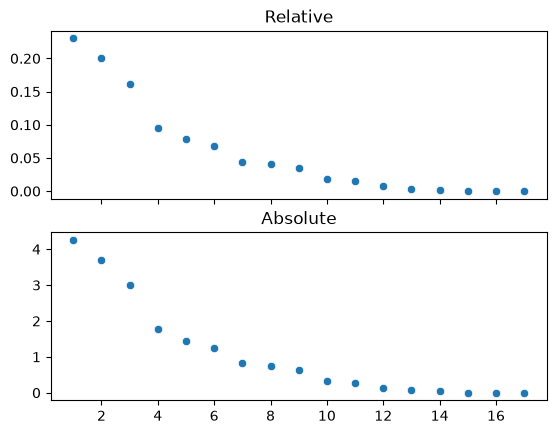

In [14]:
# Initial PCA without limits
pca, training_pcs = get_pca(training)
scree_pca(pca)

It seems our elbow is at around 4 PCs. Keep 5 to be sure.

In [15]:
# PCA restricted to most explanatory PCs
pca, training_pcs = get_pca(training, n_components = 5)

pcs = pd.DataFrame(pca.transform(exm_p_norm), index = exm_p_norm.index)
pcs.columns = [f"PC{i}" for i in pcs.columns] # Rename for clarity

In [16]:
# Residualize features
residuals = exm_p_norm - pca.inverse_transform(pcs)

In [17]:
residuals.describe()

,electricity_kwh,gasoline_gallon,household-gas_therm,housing,BLP,FF,pe_ratio,treasury_yield_3mo,treasury_yield_10y,treasury_yield_curve,GDP,fx_JPUS,fx_USEU,fx_USUK,gold,VIX,log_inflation
count,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000,10112.000000
mean,0.003195,-0.020812,-0.011736,0.026757,-0.031034,-0.043351,0.011542,0.003187,-0.082954,0.115633,-0.093846,0.002946,-0.002532,0.003322,0.000785,-0.007314,0.066248
std,0.800772,0.409809,0.077456,0.364894,0.131734,0.135231,0.038354,0.075866,0.261999,0.348981,0.282610,0.827304,0.430493,0.523229,0.765739,1.076935,0.342997
min,-2.420099,-1.214403,-0.284739,-1.075793,-0.591142,-0.611342,-0.149393,-0.399224,-0.917550,-0.745732,-0.982704,-8.934191,-2.385753,-8.236868,-3.104291,-6.528634,-1.093643
25%,-0.346844,-0.307508,-0.057879,-0.247347,-0.107087,-0.118148,-0.016114,-0.028012,-0.250592,-0.114694,-0.273954,-0.404888,-0.247229,-0.256273,-0.494565,-0.619411,-0.129514
50%,-0.082825,-0.040305,-0.010979,0.000857,-0.013573,-0.014985,0.011633,0.012613,-0.093948,0.026589,-0.107017,0.005817,0.000246,0.015499,-0.054256,-0.095873,0.053317
75%,0.292242,0.235216,0.035549,0.277325,0.071328,0.057573,0.037738,0.049224,0.101461,0.230430,0.103479,0.415920,0.239045,0.272954,0.473010,0.498784,0.214637
max,2.849935,1.231859,0.336929,1.187516,0.422402,0.731071,0.162613,0.219409,0.535252,1.946299,0.571726,5.594055,2.233901,3.298087,3.470414,11.846892,1.348940


# Identify regime clusters

We use KMeans clustering for the ease of use. A Hidden Markov Model (HMM) may be more suitable and aligns more closely with [pre-existing literature](https://www.mdpi.com/2227-7390/13/7/1128), but is currently out-of-scope.

In [18]:
from sklearn.cluster import MiniBatchKMeans

# number of clusters
n_clusters = 4
# Combine PCs and residuals
full = pcs.join(residuals)
# Can only fit on training data
training = full[full.index < split_date]

km = MiniBatchKMeans(n_clusters = n_clusters, random_state = 42)
km = km.fit(training)

clusters = pd.DataFrame(km.predict(full), index = full.index)

full["cluster"] = clusters

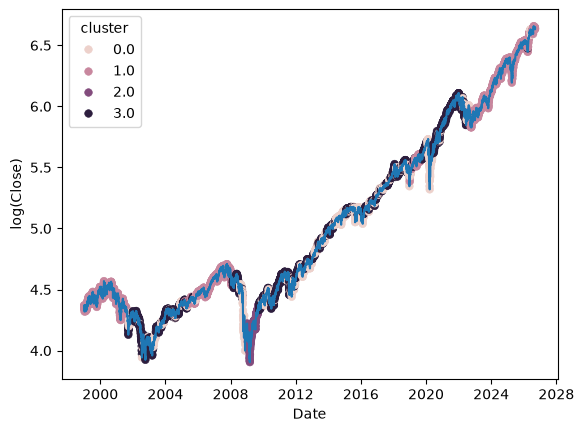

In [19]:
plot_clusters(clusters, ticker = "SPY")

## Best and worst performers per phase

We can rate the per-regime performance of asset classes via the next-day-closing returns of a representative ETF. 

There are many metrics to rate stock performance by, such as raw returns or sharpe ratio. Here, stocks are **rated by sortino ratio**, where returns are penalized for their **downside volatility only** (as opposed to bidirectional volatility with sharpe ratio). This is done in the interest of minimizing risk for leveraged positions. 

Note that the worst performers should have the lowest upside volatility instead (hence the altered "inverse" sortino formula used).

In [20]:
# Add log returns and annualized future log returns
for ticker, df in etfs.items():
    df = df.join(full["cluster"])
    
    # Annualize logret for readability
    df["logret_annual"] = df["logret"] * 252
    
    # Next-day returns
    df["f_logret"] = df["logret"].shift(-1) 
    df["f_logret_annual"] = df["logret_annual"].shift(-1)

    df["set"] = None
    df.loc[df.index < split_date, "set"] = "training"
    df.loc[df.index > split_date, "set"] = "test"

    # Write
    etfs[ticker] = df

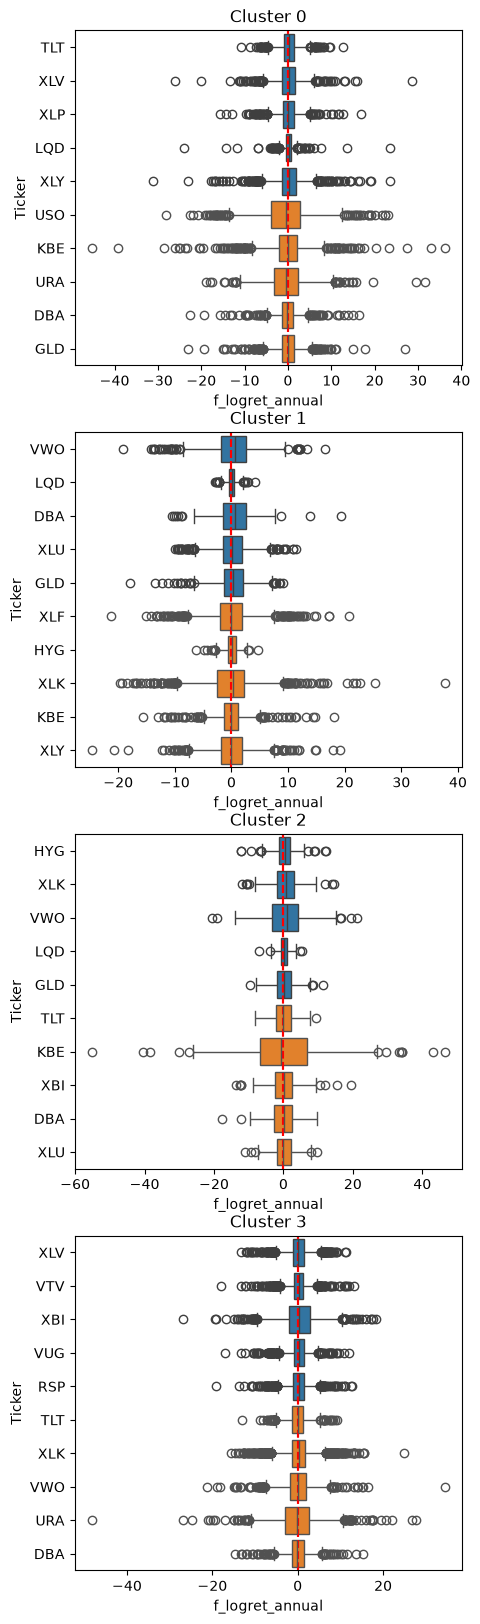

In [21]:
# Plot performance
fig, ax = plt.subplots(n_clusters, 1, figsize = (5, 20))

df = pd.concat(etfs.values()) # values() to avoid redundant multiindex

# Don't show VIX, as it is not an asset class
df = df[df["Ticker"] != "^VIX"]

'''
axis = 0
for i in ["training", "test"]:
    sns.boxplot(data = df[df["set"] == i].reset_index(), x = 'f_1d_Close_logret', y = "Ticker", 
                hue = "cluster", # orient = "v",
                ax = ax[axis],
               ).set_title(i)
    ax[axis].set_xlim(-0.10, 0.10)
    ax[axis].axvline(x = 0, color = "red", linestyle = "--")
    axis += 1
    
'''

n_tickers = 5 # How many tickers to display for each side
axis = 0
best_tickers = {}
worst_tickers = {}
for i in range(n_clusters):
    # Again, only use training data to evaluate performance pre-testing
    best_tickers_sortino = df[(df["cluster"] == i) & (df["set"] == "training")].groupby("Ticker")["f_logret_annual"].apply(lambda x: np.sum(x) / np.std(x[x < 0])).nlargest(n_tickers, keep = "first").index 
    best_tickers_sortino = list(best_tickers_sortino)
    best_tickers[i] = best_tickers_sortino

    worst_tickers_sortino = df[(df["cluster"] == i) & (df["set"] == "training")].groupby("Ticker")["f_logret_annual"].apply(lambda x: -np.sum(x) / np.std(x[x > 0])).nlargest(n_tickers, keep = "first").index 
    worst_tickers_sortino = list(worst_tickers_sortino)
    worst_tickers[i] = worst_tickers_sortino

    for j in [best_tickers_sortino, worst_tickers_sortino]:
        sns.boxplot(data = df[(df["cluster"] == i) & (df["set"] == "training") & (df["Ticker"].isin(j))].reset_index(), x = 'f_logret_annual', y = "Ticker", 
                    # hue = "set", # orient = "v",
                    ax = ax[axis],
                   ).set_title(f"Cluster {i}")
        # ax[axis].set_xlim(-1, 1)
        ax[axis].axvline(x = 0, color = "red", linestyle = "--")

    
    axis += 1
        
plt.show()
plt.close()

# Statistical testing

Note that <u>**all of statistical tests are only performed on training data!**</u> We want to establish a "realistic" strategy based on data available in 2019 to backtest later.

alpha p < 0.10 is chosen as significant. This is high in relation to traditional p-values. The justification is that less-significant differences in return distributions may still provide economically relevant results. This is also the reason I will not be adjusting for the multiple comparisons problem of testing many asset classes.

In [22]:
alpha = 0.1

## Between regimes

### Expected returns

To estimate the expected return for each asset class in each regime (and wether it differs meaningfully from zero) we make use of a **simple OLS linear regression** model. Note that **returns are logarithmic and annualized**.

In [23]:
import statsmodels.formula.api as smf

In [24]:
# Between-regime expected returns testing
def br_er_test(etfs, set_ = "training", alpha = 0.10):
    print("Significant OLS linear regression results:")
    
    for ticker, df in etfs.items():
        if set_ is not None: df = df[df["set"] == set_] # Test only on training data!
        df["cluster"] = df["cluster"].astype("category")
    
        x_cols = ["cluster", ]
        y_col = ["f_logret_annual"] # List for ease-of-use. Should be one var.

        df = df[x_cols + y_col].dropna(how = "any") # remove all NAs
    
        x = df[x_cols]
        y = df[y_col] # Easier interpretation because of annualization

        # x = smf.add_constant(x) # Add intercept
    
        model = smf.ols(
            "f_logret_annual ~ C(cluster)",
            data = df
        ).fit()

        p_under_alpha = model.pvalues[model.pvalues < alpha]
        if not p_under_alpha.empty:
            p_values = model.pvalues[model.pvalues < alpha]
            params = model.params # .loc[list(set(p_values.index).add("Intercept"))]
            result_df = pd.DataFrame([p_values, params], index = ["p", "param"]).T
            print(f"{ticker}: \n{result_df}\n")

In [25]:
br_er_test(etfs, set_ = "training", alpha = alpha)

Significant OLS linear regression results:
USO: 
                        p     param
Intercept        0.000015 -0.701828
C(cluster)[T.1]  0.008414  0.783600
C(cluster)[T.2]  0.088007  0.724213
C(cluster)[T.3]  0.000053  0.869842

TLT: 
                        p     param
Intercept        0.002355  0.179223
C(cluster)[T.2]  0.035115 -0.349333
C(cluster)[T.3]  0.024460 -0.170436
C(cluster)[T.1]       NaN -0.124751

VWO: 
                        p     param
C(cluster)[T.2]  0.088024  0.615957
Intercept             NaN -0.061172
C(cluster)[T.1]       NaN  0.258157
C(cluster)[T.3]       NaN  0.080408

LQD: 
                        p     param
Intercept        0.010039  0.086745
C(cluster)[T.1]       NaN -0.045753
C(cluster)[T.2]       NaN  0.030701
C(cluster)[T.3]       NaN -0.059434

URA: 
                        p     param
Intercept        0.049568 -0.336721
C(cluster)[T.3]       NaN  0.170747

DBA: 
                        p     param
Intercept        0.051844 -0.170005
C(cluster)[T.1] 

**IMPORTANT**: "Intercept" (I) here is regime 0, used as a baseline, and each slope (T) is for subsequent regimes.

Thus expected return (E) for each regime can be calculated as:<br> <u>E(0) = I; E(1) = I + T1; E(2) = I + T2; ..</u>

We can see that **several asset classes have returns significantly higher/lower than 0 dependent on the regime**. 
The most important results per regime are:

- Most assets seem to be **in turmoil in regime 0** (E < -17%). Notable **exceptions** are both **government bonds** (TLT) and **corporate bonds** (LQD). **US oil** (USO) is especially vulnerable to these downturns (E = -70%).
- **Regime 1** seems to indicate strong growth (E > 26%) periods for **gold** (GLD) and **agriculture** (DBA).
- **Emerging markets** (VWO) seem to grow strongly in **regime 2**.
- Besides **US oil performing well** (E = 17%), **regime 3** has the least interesting significant results

### Distributions

Differences in return distributions are informative as to how asset classes behave in certain regimes. As we cannot assume neither normal distributions nor heteroscedasticity, the use of a non-parametric test will give the most accurate results for comparing return distributions between and within asset classes and regimes. For this we use the **Kruskal-Wallis test**.

In [26]:
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn as dunn

In [27]:
# Between-regime distribution-differences test
def br_dist_test(etfs, set_ = "training", alpha = 0.10): 
    br_dfs = {} # Dict of between-regime cluster future returns
    for ticker, df in etfs.items():
        if set_ is not None: df = df[df["set"] == set_] # Use only training/test data!
        result = df.groupby("cluster")["f_logret"].apply(list).apply(pd.Series).T

        result.columns.name = None   

        br_dfs[ticker] = result

    print("\nKruskal-Wallis significant results:")
    sig_br = {} # Significant tickers
    for ticker, df in br_dfs.items():
        df_l = [list(df[c]) for c in df.columns] # Split needed for scipy API
        H_stat, p_stat = kruskal(*df_l, nan_policy = "omit")
        if p_stat < alpha:
            print(f"Ticker: {ticker}; H: {H_stat}; p: {p_stat}")
            sig_br[ticker] = df

    print("\nSignificant Dunn post-hoc results:")
    for ticker, df in sig_br.items():
        df_l = [list(df[c]) for c in df.columns] # Split needed for scipy API
        du = dunn(df_l, p_adjust = "bonferroni")
        print(f"Ticker: {ticker} \n{du[du < alpha]}\n")

In [28]:
br_dist_test(etfs, set_ = "training", alpha = alpha)


Kruskal-Wallis significant results:
Ticker: USO; H: 16.682633556313135; p: 0.0008212972417977688
Ticker: VWO; H: 7.874155099837058; p: 0.04868541359041003
Ticker: DBA; H: 12.71209059096825; p: 0.0053024597131813905
Ticker: GLD; H: 9.921548309558895; p: 0.019244911129219115

Significant Dunn post-hoc results:
Ticker: USO 
          1   2   3         4
1       NaN NaN NaN  0.000459
2       NaN NaN NaN       NaN
3       NaN NaN NaN       NaN
4  0.000459 NaN NaN       NaN

Ticker: VWO 
    1   2   3   4
1 NaN NaN NaN NaN
2 NaN NaN NaN NaN
3 NaN NaN NaN NaN
4 NaN NaN NaN NaN

Ticker: DBA 
          1         2   3         4
1       NaN  0.002812 NaN       NaN
2  0.002812       NaN NaN  0.072338
3       NaN       NaN NaN       NaN
4       NaN  0.072338 NaN       NaN

Ticker: GLD 
         1        2   3   4
1      NaN  0.01123 NaN NaN
2  0.01123      NaN NaN NaN
3      NaN      NaN NaN NaN
4      NaN      NaN NaN NaN



<u>**BEWARE NON-ZERO BASED INDEX IN DUNN POST-HOC!**</u> Subtract all indices by 1 to get the corresponding regime.

From the **Kruskal-Wallis results**, it seems **US oil, agriculture, emerging markets and gold** have significantly altered **return distributions** (p < 0.5) **depending on market regime**. However, **emerging markets lose their significance** in **post-hoc Dunn** testing.

These results can be used to confirm several observations in our previous expected return testing.

- **US oil** performs differently in regime 0 vs 3, consistent with their respective dismal and good expected returns.
- **Agriculture** returns are differently distributed in regime 1 vs 0 & 3. This strengthens previous observations of high DBA expected returns in regime 1.
- **Gold** similarly behaves differently in regime 1 vs 0, consistent with above-average expected return.

Other asset classes not showing significance in these tests does not mean we should discount previous results in OLS regression. Rather, we should **focus on gold, oil & agriculture** as our strongest/most consistent signals.

## Between asset classes

### Mean returns

Between asset classes, we are less interested in return distribution difference (as most asset classes have a "unique" distribution anyways). Instead, a **pure difference in mean returns** is more valuable information. A suitable test would be **Welch's ANOVA**. Beware we still violate the assumption of normal distribution!

In [29]:
from scipy.stats import f_oneway as anova
from scipy.stats import tukey_hsd

In [30]:
# Between asset classes mean returns differences test
def ba_mr_test(etfs, set_ = "training", alpha = alpha):
    ba_dfs = {} # Dict of per-regime between-asset future returns

    for cluster in range(n_clusters):
        ba_dfs[cluster] = pd.DataFrame()

    ###
    # TODO: Adapt to get ba_dfs directly from etfs
    ###
    br_dfs = {} # Dict of between-regime cluster future returns
    for ticker, df in etfs.items():
        if set_ is not None: df = df[df["set"] == set_] # Use only training data!
        result = df.groupby("cluster")["f_logret"].apply(list).apply(pd.Series).T

        result.columns.name = None   

        br_dfs[ticker] = result
        
    for ticker, df in br_dfs.items():
        for cluster in df.columns:
            ba_dfs[cluster][ticker] = df[cluster]

    print("Welch's ANOVA results:")
    sig_ba = {} # Significant tickers
    for cluster, df in ba_dfs.items():
        df_l = [list(df[t]) for t in df.columns] # Split needed for scipy API
        F_stat, p_stat = anova(*df_l, nan_policy = "omit", 
                               equal_var = False) # Specifically use Welch's ANOVA
        if p_stat < alpha:
            print(f"Cluster: {cluster}; H: {F_stat}; p: {p_stat}")
            sig_ba[cluster] = df

    print("Tukey's post-hoc results:")
    for cluster, df in sig_ba.items():
        print(pd.DataFrame(df.columns, list(range(len(df.columns)))))
        df_l = [list(df[t].dropna(how = "any")) for t in df.columns] # Split needed for scipy API
        result = tukey_hsd(*df_l, equal_var = False)
        print(result)

In [31]:
ba_mr_test(etfs, set_ = "training", alpha = alpha)

Welch's ANOVA results:
Cluster: 0; H: 1.717293314853504; p: 0.014375235569337383
Tukey's post-hoc results:
      0
0   XLF
1   USO
2   PHO
3   TLT
4   HYG
5   XLV
6   XLK
7   XLP
8   VTV
9   ITA
10  XLB
11  VWO
12  KBE
13  LQD
14  URA
15  XLY
16  XBI
17   VT
18  DBA
19  EMB
20  XLU
21  VNQ
22  IWM
23  VUG
24  RSP
25  GLD
Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      0.003     0.296    -0.001     0.006
 (0 - 2)      0.000     1.000    -0.002     0.003
 (0 - 3)     -0.001     1.000    -0.003     0.001
 (0 - 4)     -0.000     1.000    -0.002     0.002
 (0 - 5)     -0.000     1.000    -0.003     0.002
 (0 - 6)     -0.000     1.000    -0.003     0.002
 (0 - 7)     -0.000     1.000    -0.003     0.002
 (0 - 8)     -0.000     1.000    -0.003     0.002
 (0 - 9)     -0.000     1.000    -0.003     0.002
 (0 - 10)     -0.000     1.000    -0.003     0.002
 (0 - 11)      0.000     1.000    -0.003     0.003
 (0 - 12)      0.00

Only **regime 0** (p = 0.013) seems to have significant differences in returns between asset classes. Because of the sheer amount of asset classes, it is doubtful that this will survive post-hoc multiple testing correction. 

From these results, it seems **USO** consistently has a significantly different mean from all other asset classes in **regime 0**. This tracks with our previous observation of **extreme turmoil for oil markets during regime 0** in between-regime testing! 

### Correlation

Another avenue for exploration is the use of asset correlations in different regimes. By identifying regime-specific uncorrelated assets, we can **optimize our portfolio's "free lunch" in diversification**.

Correlation-based strategies could also use **Dunett's test** as an ANOVA post-hoc to identify which asset's mean returns **differ from a single control**. We could select a **"benchmark" asset** as a control, which would be the **base investment of our portfolio held across all regimes**. An example benchmark could be the SPY or RSP, or the combined return of holding all assets equally. A different mean return could then be an **indication of strong benchmark-uncorrelated behaviour**. We could then hold presumably uncorrelated assets on a per-regime basis to hedge against typical market behaviour of our benchmark. <br>Dunn's test does however assume equal variances, and selecting a "true" benchmark is difficult. 

# Testing validation

As we did our analyses in the training dataset (pre-2019), we now want to validate the observations in unseen test data (post-2019). 

## Backtesting

We can evaluate performance of our strategy by summing the next-day-closing returns for our holdings each day (or subtracting when taking a short position). Then, we compare to our defualt-stock benchmark (BM), just hold all (JH) and/or random buys (RB) strategies to assess performance.

### Long-Short portfolio

A simple way to exploit our regime information is to **long predicted overperformers and short underperformers**. This would mean we:
- Regime 0: Long govt & corporate bonds (TLT & LQD); Short oil (USO) (and possibly also nuclear (URA) & agriculture (DBA))
- Regime 1: Long gold (GLD) & DBA; Possibly short TLT
- Regime 2: Long emerging markets (VWO);
- Regime 3: Long USO;

In [32]:
from regime_identification.Modelling.backtesting import backtest_strategies

In [33]:
'''
The "strategy" is a df where each column is a condition (here: regime) and each row an asset.
Location [asset, condition] represents how much of an asset to buy in that condition.
Values indicate the ratio of the portfolio to allocate to the asset proportional to other assets. 
Ratios are adjusted to total an absolute value of 1 per condition.
'''

etfs_names = list(etfs.keys())
n_clusters = n_clusters 

strategy = pd.DataFrame(np.nan, index = etfs_names, columns = np.arange(n_clusters))

# Regime 0: Long TLT & LQD; Short USO
strategy.loc[["TLT", "LQD"], 0] = 1
strategy.loc[["USO"], 0] = -1 # We could select a higher ratio, as we have very strong conclusions for USO specifically

# Regime 1: Long GLD & DBA; Short TLT
strategy.loc[["GLD", "DBA"], 1] = 1
strategy.loc[["TLT"], 1] = -1

# Regime 2: Long VWO
strategy.loc[["VWO"], 2] = 3 # Sum everything to 3 for some easier strategy additions later

# Regime 3: Long USO
strategy.loc[["USO"], 3] = 3

In [34]:
strategy.dropna(how = "all") # Visual representation of our strategy

,0,1,2,3
USO,-1.0,NaN,NaN,3.0
TLT,1.5,-1.0,NaN,NaN
VWO,NaN,NaN,3.0,NaN
LQD,1.5,NaN,NaN,NaN
DBA,NaN,1.0,NaN,NaN
GLD,NaN,1.0,NaN,NaN


In [35]:
# Benchmark strategies
jh = pd.DataFrame(1, index = etfs_names, columns = np.arange(n_clusters)) # hold all
bm = pd.DataFrame(1, index = ["RSP"], columns = np.arange(n_clusters)) # RSP only

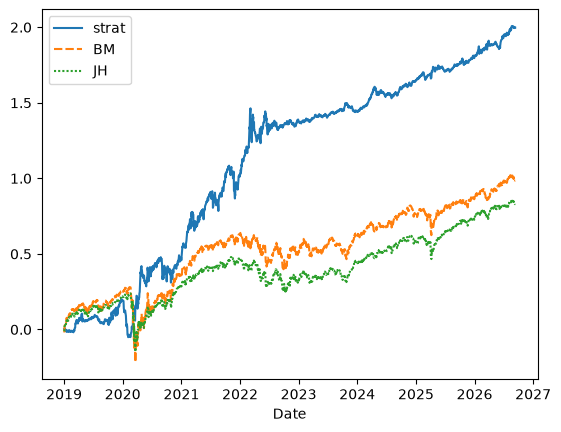

In [36]:
strat_dfs = backtest_strategies(etfs, condition_col = "cluster",
                                  strategies = {"strat": strategy, "BM": bm, "JH": jh},
                                  start_date = split_date, plot = True)

In [37]:
def get_performance(df): # Make sure df is in logret
    # Replace 0 with nan
    df = df["total"]

    ret = f"{int(df.sum() * 100)}%"
    sharpe = df.mean() * np.sqrt(252) / df.std() # annualize for readability
    sortino = df.mean() * np.sqrt(252) / df[df < 0].std()

    print(f"return: {ret}\nsharpe: {sharpe}\nsortino: {sortino}")


    

In [38]:
for name, df in strat_dfs.items():
    print(f"\n{name}:")
    get_performance(df)


strat:
return: 199%
sharpe: 1.1803131151781932
sortino: 1.3782693302919056

BM:
return: 98%
sharpe: 0.6459828449044122
sortino: 0.7761840952897011

JH:
return: 83%
sharpe: 0.6990575342594945
sortino: 0.8081766408885995


WOW! We hypothetically outperformed the market by quite a large margin, both in raw return and risk-adjusted returns.

### Long-Short + exposure portfolio

There are significant risks associated with the previous Long-Short portfolio: **Lack of diversification** (in some regimes)

We lose out on a significant level of market exposure, as well as exposing ourselves to issues with non-diversified risk such as [the turkey illusion](https://en.wikipedia.org/wiki/Turkey_illusion) (especially in regime 2 and 3). This can be **mediated by investing in a "default" stock** and diversifying our market exposure risk with the addition of our long-short strategy. 

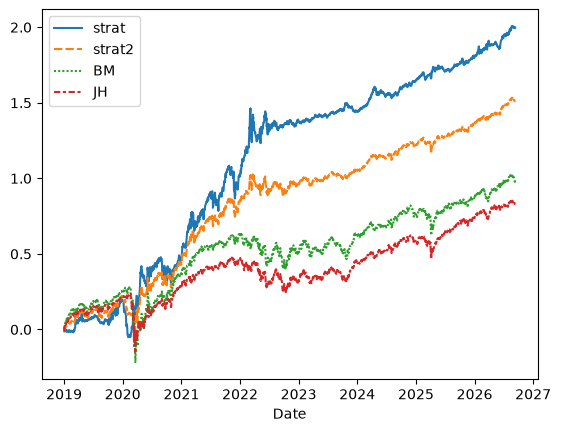

In [39]:
# Add a default stock
strategy2 = strategy.copy()
strategy2.loc[["RSP"], :] = 3 # 50% in RSP, 50% in our strategy

# Test again
strat_dfs = backtest_strategies(etfs, condition_col = "cluster",
                                  strategies = {"strat": strategy, "strat2": strategy2, "BM": bm, "JH": jh},
                                  start_date = split_date, plot = True)

In [40]:
get_performance(strat_dfs["strat2"])

return: 151%
sharpe: 1.2950207885386322
sortino: 1.606418771821353


While the total return for our exposure strategy is not as high as the pure Long-Short portfolio, it does have a **better risk-adjusted return** in both Sharpe and Sortino ratio.

### Maximum diversification portfolio

We can further exploit information on between-asset correlation during regimes to maximize diversification and reduce exposure to market fluctuations (e.g. optimize sharp/sortino ratio). This could be especially interesting to explore with leveraged positions as a way to minimize drawdowns.

In [ ]:
# W.I.P.

## Statistical testing

We can repeat our same statistical tests to see if the stats held throughout the entire observational period and/or the test period by itself.

### Whole dataset

In [41]:
# Between regimes
## Distribution differences
br_dist_test(etfs, set_ = None, alpha = alpha)
## Return differences
br_er_test(etfs, set_ = None, alpha = alpha)

# Between asset classes
## Mean returns differences 
ba_mr_test(etfs, set_ = None, alpha = alpha)


Kruskal-Wallis significant results:
Ticker: USO; H: 26.405285681642983; p: 7.844249532810789e-06
Ticker: DBA; H: 13.657820695046414; p: 0.0034099282757600493
Ticker: GLD; H: 14.222296415561148; p: 0.002617666225890937

Significant Dunn post-hoc results:
Ticker: USO 
          1         2   3         4
1       NaN  0.000711 NaN  0.000004
2  0.000711       NaN NaN       NaN
3       NaN       NaN NaN       NaN
4  0.000004       NaN NaN       NaN

Ticker: DBA 
          1         2   3         4
1       NaN  0.001453 NaN  0.096839
2  0.001453       NaN NaN       NaN
3       NaN       NaN NaN       NaN
4  0.096839       NaN NaN       NaN

Ticker: GLD 
          1         2   3   4
1       NaN  0.001053 NaN NaN
2  0.001053       NaN NaN NaN
3       NaN       NaN NaN NaN
4       NaN       NaN NaN NaN

Significant OLS linear regression results:
USO: 
                            p     param
Intercept        4.245388e-07 -0.835674
C(cluster)[T.1]  1.031301e-05  0.983178
C(cluster)[T.2]  6.46207

### Test-only

In [42]:
# Between regimes
## Distribution differences
br_dist_test(etfs, set_ = "test", alpha = alpha)
## Return differences
br_er_test(etfs, set_ = "test", alpha = alpha)

# Between asset classes
## Mean returns differences 
ba_mr_test(etfs, set_ = "test", alpha = alpha)


Kruskal-Wallis significant results:
Ticker: USO; H: 6.407140254477912; p: 0.040616937188380275

Significant Dunn post-hoc results:
Ticker: USO 
          1   2         3
1       NaN NaN  0.051436
2       NaN NaN       NaN
3  0.051436 NaN       NaN

Significant OLS linear regression results:
USO: 
                        p     param
Intercept        0.001077 -1.576199
C(cluster)[T.1]  0.000819  1.751124
C(cluster)[T.3]  0.000228  2.043929
C(cluster)[T.2]       NaN  0.000000



/tmp/ipykernel_85697/1987392652.py:22: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()
/tmp/ipykernel_85697/1987392652.py:22: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()
/tmp/ipykernel_85697/1987392652.py:22: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()
/tmp/ipykernel_85697/1987392652.py:22: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()
/tmp/ipykernel_85697/1987392652.py:22: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()
/tmp/ipykernel_85697/1987392652.py:22: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ).fit()
/tmp/ipykernel_85697/1987392652.py:22: Singula

Welch's ANOVA results:


TypeError: At least two samples are required; got 0.

As we can see, **very little results are replicated in the testing analysis only**. 